# Muon Ablations

Analysis of ablation experiments on the Muon optimizer for the parameter-golf project.

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import wandb
import importlib, utils
importlib.reload(utils)
from utils import apply_style
apply_style(force=True)

ENTITY  = "the-golfers"
PROJECT = "ml_ai_project"

api = wandb.Api()

## BASELINE 

In [23]:
BASELINE_PREFIX = "golf_baseline_antonio_new"

baseline_runs = api.runs(
    f"{ENTITY}/{PROJECT}",
    filters={"display_name": {"$regex": f"^{BASELINE_PREFIX}"}},
)




baseline_rows = []
for run in baseline_runs:
    summary = run.summary._json_dict
    baseline_rows.append({
        "run_name":         run.name,
        "seed":             run.config.get("seed"),
        "final_val_bpb":    summary.get("final_val_bpb"),
        "final_val_loss":   summary.get("final_val_loss"),
        "quant_file_bytes": summary.get("quant_file_bytes"),
    })

df_base = pd.DataFrame(baseline_rows).sort_values("seed").reset_index(drop=True)

# Summary stats
mean_bpb  = df_base["final_val_bpb"].mean()
std_bpb   = df_base["final_val_bpb"].std()
mean_loss = df_base["final_val_loss"].mean()
std_loss  = df_base["final_val_loss"].std()

print("=" * 50)
print("BASELINE RESULTS  (3 seeds)")
print("=" * 50)
print(df_base[["seed", "final_val_bpb", "final_val_loss", "quant_file_bytes"]].to_string(index=False))
print()
print(f"final_val_bpb  :  {mean_bpb:.4f} ± {std_bpb:.4f}")
print(f"final_val_loss :  {mean_loss:.4f} ± {std_loss:.4f}")
print("=" * 50)

BASELINE RESULTS  (3 seeds)
 seed  final_val_bpb  final_val_loss  quant_file_bytes
   42       1.311341        2.214144          15777299
  123       1.309026        2.210235          15783532
 1337       1.310237        2.212280          15770704

final_val_bpb  :  1.3102 ± 0.0012
final_val_loss :  2.2122 ± 0.0020


## Ablation 1 — matrix_lr sweep

Sweep over `matrix_lr` values `[0.02, 0.04, 0.06, 0.08]` with 1 seed each, 5000 steps.

In [24]:
RUN_ID_PREFIX = "ablation1_matrix_lr"  # change if you used a different RUN_ID

runs = api.runs(
    f"{ENTITY}/{PROJECT}",
    filters={"display_name": {"$regex": f"^{RUN_ID_PREFIX}"}},
)

rows = []
for run in runs:
    summary = run.summary._json_dict
    config  = run.config
    rows.append({
        "run_name":         run.name,
        "matrix_lr":        config.get("matrix_lr"),
        "seed":             config.get("seed"),
        "final_val_bpb":    summary.get("final_val_bpb"),
        "final_val_loss":   summary.get("final_val_loss"),
        "quant_file_bytes": summary.get("quant_file_bytes"),
    })

df = pd.DataFrame(rows).sort_values("matrix_lr").reset_index(drop=True)
df

,run_name,matrix_lr,seed,final_val_bpb,final_val_loss,quant_file_bytes
0,ablation1_matrix_lr_lr0p0200_seed1337,0.02,1337,1.311323,2.214114,15114367
1,ablation1_matrix_lr_lr0p0400_seed1337,0.04,1337,1.309804,2.211549,15777570
2,ablation1_matrix_lr_lr0p0600_seed1337,0.06,1337,1.313065,2.217055,15757351
3,ablation1_matrix_lr_lr0p0800_seed1337,0.08,1337,1.314294,2.219130,15733239


In [25]:
best = df.loc[df["final_val_bpb"].idxmin()]
print(f"Best matrix_lr : {best['matrix_lr']}")
print(f"final_val_bpb  : {best['final_val_bpb']:.4f}")
print(f"final_val_loss : {best['final_val_loss']:.4f}")

Best matrix_lr : 0.04
final_val_bpb  : 1.3098
final_val_loss : 2.2115


### Final val_bpb bar chart

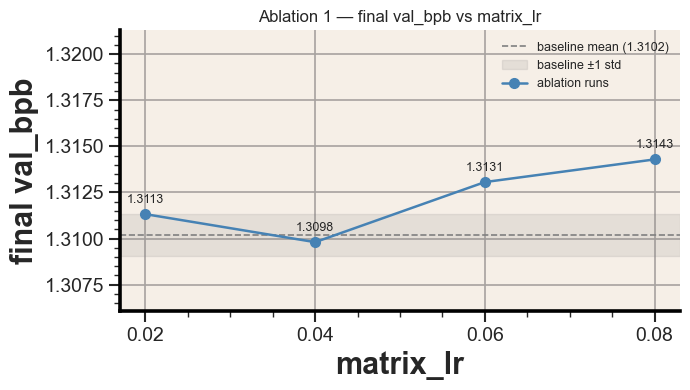

In [26]:
fig, ax = plt.subplots(figsize=(7, 4))

# baseline band
ax.axhline(mean_bpb, color="gray", linestyle="--", linewidth=1.2, label=f"baseline mean ({mean_bpb:.4f})")
ax.axhspan(mean_bpb - std_bpb, mean_bpb + std_bpb, alpha=0.15, color="gray", label=f"baseline ±1 std")

# ablation points connected by a line
lrs = df["matrix_lr"].values
vals = df["final_val_bpb"].values
ax.plot(lrs, vals, marker="o", linewidth=1.8, markersize=7, color="steelblue", label="ablation runs")

# annotate each point
for lr, v in zip(lrs, vals):
    ax.annotate(f"{v:.4f}", xy=(lr, v), xytext=(0, 8), textcoords="offset points",
                ha="center", fontsize=9)

# zoom y-axis to the interesting range
margin = 0.003
ax.set_ylim(min(vals.min(), mean_bpb - std_bpb) - margin,
            max(vals.max(), mean_bpb + std_bpb) + margin + 0.004)

ax.set_xlabel("matrix_lr")
ax.set_ylabel("final val_bpb")
ax.set_title("Ablation 1 — final val_bpb vs matrix_lr")
ax.set_xticks(lrs)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


### Learning curves (val_bpb and train_loss)

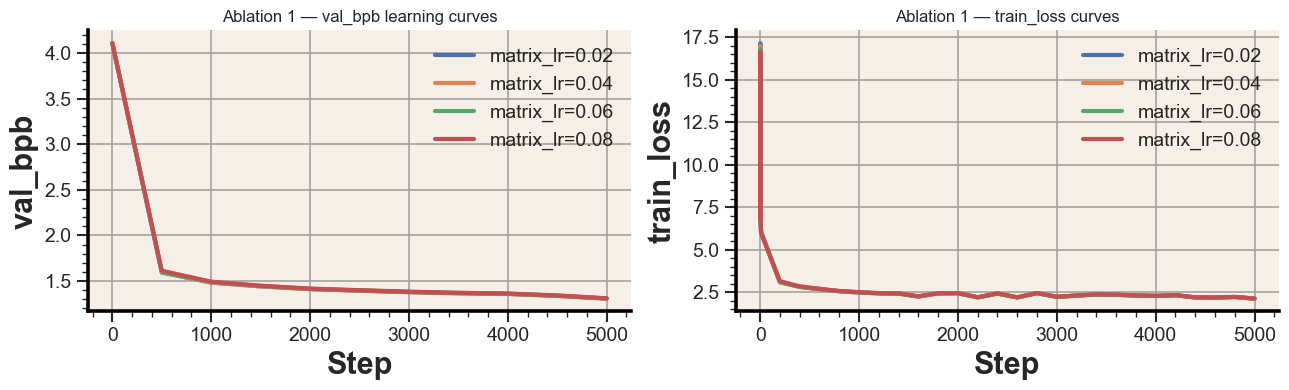

In [27]:
def fetch_history(run_id_prefix, metric):
    runs = api.runs(
        f"{ENTITY}/{PROJECT}",
        filters={"display_name": {"$regex": f"^{run_id_prefix}"}},
    )
    histories = {}
    for run in runs:
        hist = run.history(keys=["_step", metric], pandas=True)
        if not hist.empty:
            hist = hist.rename(columns={"_step": "step"}).dropna()
            label = run.config.get("matrix_lr", run.name)
            histories[label] = hist
    return dict(sorted(histories.items()))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for metric, ax, title in [
    ("val_bpb",    axes[0], "val_bpb learning curves"),
    ("train_loss", axes[1], "train_loss curves"),
]:
    for lr, hist in fetch_history(RUN_ID_PREFIX, metric).items():
        ax.plot(hist["step"], hist[metric], label=f"matrix_lr={lr}")
    ax.set_xlabel("Step")
    ax.set_ylabel(metric)
    ax.set_title(f"Ablation 1 — {title}")
    ax.legend()

plt.tight_layout()
plt.show()

### Gradient norms

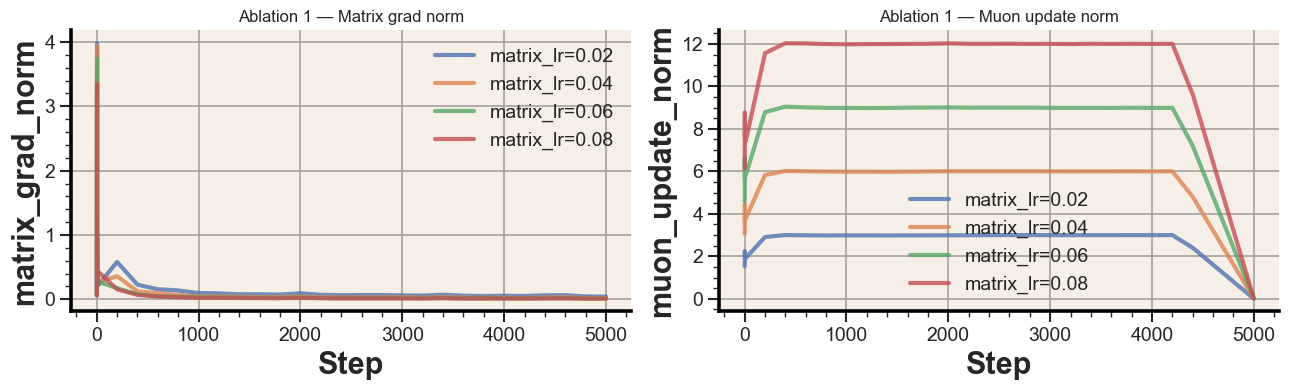

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for metric, ax, title in [
    ("matrix_grad_norm", axes[0], "Matrix grad norm"),
    ("muon_update_norm", axes[1], "Muon update norm"),
]:
    for lr, hist in fetch_history(RUN_ID_PREFIX, metric).items():
        ax.plot(hist["step"], hist[metric], label=f"matrix_lr={lr}", alpha=0.8)
    ax.set_xlabel("Step")
    ax.set_ylabel(metric)
    ax.set_title(f"Ablation 1 — {title}")
    ax.legend()

plt.tight_layout()
plt.show()